In [1]:
import json
import os
import glob
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import matplotlib.patches as mpatches
from collections import OrderedDict
from collections import Counter, defaultdict, OrderedDict

import statsmodels.api as sm
from scipy.stats import norm
from scipy.interpolate import interp1d

%config InlineBackend.figure_format='retina'

In [2]:
n_folders = len([f for f in os.listdir("../manuscripts") if os.path.isdir(os.path.join("/Users/laura/Documents/TBC/evals/manuscripts", f))])
print(n_folders)

18576


In [4]:
# -- Load only manuscripts/versions listed in ../data/jids.txt --
base_path = "../manuscripts"
dfs_claims = []
dfs_llm = []

with open("../data/jids.txt") as f:
    for line in f:
        entry = line.strip()
        if not entry or "/" not in entry:
            continue
        manuscript_id, version_dir = entry.split("/")
        version = version_dir.split("-")[-1]
        manuscript_path = os.path.join(base_path, manuscript_id, version)
        
        # Load claims.json
        claims_json_path = os.path.join(manuscript_path, "claims.json")
        if os.path.exists(claims_json_path):
            with open(claims_json_path, "r") as claims_file:
                claims = json.load(claims_file)
            df_claims_part = pd.DataFrame(claims)
            df_claims_part["manuscript_id"] = manuscript_id
            df_claims_part["version"] = version
            dfs_claims.append(df_claims_part)
        
        # Load eval_llm.json
        eval_llm_path = os.path.join(manuscript_path, "eval_llm.json")
        if os.path.exists(eval_llm_path):
            with open(eval_llm_path, "r") as eval_llm_file:
                eval_llm = json.load(eval_llm_file)
            df_llm_part = pd.DataFrame(eval_llm)
            df_llm_part["manuscript_id"] = manuscript_id
            df_llm_part["version"] = version
            dfs_llm.append(df_llm_part)

# Concatenate claims dataframes
df_claims = pd.concat(dfs_claims, ignore_index=True)

# Concatenate llm evaluation dataframes
df_llm = pd.concat(dfs_llm, ignore_index=True)

# Check for multiple versions per manuscript_id (should only be one version per manuscript)
claims_versions = df_claims.groupby("manuscript_id")["version"].nunique()
claims_multi_version = claims_versions[claims_versions > 1]
if not claims_multi_version.empty:
    print("WARNING: Found multiple versions for the same manuscript_id:")
    print(claims_multi_version)

llm_versions = df_llm.groupby("manuscript_id")["version"].nunique()
llm_multi_version = llm_versions[llm_versions > 1]
if not llm_multi_version.empty:
    print("WARNING: Found multiple versions for the same manuscript_id in llm data:")
    print(llm_multi_version)

manuscript_id
elife-96357    2
Name: version, dtype: int64
manuscript_id
elife-96357    2
Name: version, dtype: int64


In [6]:
# Remove "elife-96357" version "v1" from all dataframes
df_claims = df_claims[~((df_claims['manuscript_id'] == "elife-96357") & (df_claims['version'] == "v1"))].reset_index(drop=True)
df_llm = df_llm[~((df_llm['manuscript_id'] == "elife-96357") & (df_llm['version'] == "v1"))].reset_index(drop=True)

In [7]:
df_claims

,claim_id,claim,claim_type,source,source_type,evidence,evidence_type,manuscript_id,version
0,C1,Histones are bound to cytosolic lipid droplets...,EXPLICIT,We previously discovered histones bound to cyt...,[TEXT],This is stated in the abstract and supported b...,"[CITATION, DATA]",elife-00003,v1
1,C2,In the presence of bacterial lipopolysaccharid...,EXPLICIT,Sequestered on droplets under normal condition...,[TEXT],Demonstrated by Western blot analysis showing ...,[DATA],elife-00003,v1
2,C3,Droplet-bound histones kill bacteria efficient...,EXPLICIT,Sequestered on droplets under normal condition...,[TEXT],Supported by colony forming assays and disc di...,[DATA],elife-00003,v1
3,C4,Bacteria grow rapidly when injected into Droso...,EXPLICIT,Droplet-bound histones also function in vivo: ...,[TEXT],Demonstrated by GFP-labeled bacteria showing m...,[DATA],elife-00003,v1
4,C5,Bacteria die when injected into embryos with d...,EXPLICIT,"In contrast, bacteria injected into embryos wi...",[TEXT],Shown by decreasing bacterial numbers over tim...,[DATA],elife-00003,v1
...,...,...,...,...,...,...,...,...,...
1964597,C99,Unpaired cytokines from tumors and from entero...,EXPLICIT,Other reports indicate that Unpaired cytokines...,[TEXT],Supported by citations to published literature.,[CITATION],elife-99999,v1
1964598,C100,One effect of glial JAK–STAT activity is the a...,EXPLICIT,One effect of glial JAK–STAT activity seems to...,[TEXT],Supported by citations to published literature.,[CITATION],elife-99999,v1
1964599,C101,BBB permeability has been linked to homeostati...,EXPLICIT,One effect of glial JAK–STAT activity seems to...,[TEXT],Supported by citation to published literature.,[CITATION],elife-99999,v1
1964600,C102,The endocytic activity of BBB glia has been as...,EXPLICIT,"Furthermore, the endocytic activity of BBB gli...",[TEXT],Supported by citation to published literature.,[CITATION],elife-99999,v1


In [14]:
df_llm

,result_id,claim_ids,result,reviewer_id,reviewer_name,evaluation_type,evaluation,result_type,manuscript_id,version
0,R1,"[C1, C13, C16, C17, C18, C19, C20, C21]",Lipid droplets (LDs) from Drosophila embryos p...,OpenEval,OpenEval,SUPPORTED,"Claims C13, C16, C18, C20 provide converging e...",MAJOR,elife-00003,v1
1,R2,"[C2, C63, C64, C70, C71, C72, C73, C107]",Histones are stably bound to lipid droplets un...,OpenEval,OpenEval,SUPPORTED,"Claims C63-C64 establish baseline stability, w...",MAJOR,elife-00003,v1
2,R3,"[C27, C28, C29, C30, C31]",Jabba is a novel protein required for histone ...,OpenEval,OpenEval,SUPPORTED,Multiple independent lines of evidence support...,MAJOR,elife-00003,v1
3,R4,"[C4, C5, C37, C38, C39, C40, C42, C43, C44, C4...",Droplet-bound histones control bacterial growt...,OpenEval,OpenEval,SUPPORTED,The time-course imaging data (Figure 3C) provi...,MAJOR,elife-00003,v1
4,R5,"[C6, C36, C48, C49, C50, C51, C52, C94]",Embryos with droplet-bound histones show more ...,OpenEval,OpenEval,SUPPORTED,The survival data (Figure 3D) demonstrates con...,MAJOR,elife-00003,v1
...,...,...,...,...,...,...,...,...,...,...
298700,R6,"[C72, C73, C74, C75, C76, C77]","Blood-brain barrier (BBB) glial cells, specifi...",OpenEval,OpenEval,SUPPORTED,The anatomical specificity is demonstrated by ...,MAJOR,elife-99999,v1
298701,R7,"[C7, C78, C79, C80, C81, C82, C83, C84, C85, C...",The enteric peptide Allatostatin A (AstA) acts...,OpenEval,OpenEval,SUPPORTED,The expression pattern is established by repor...,MAJOR,elife-99999,v1
298702,R8,"[C8, C81, C82, C83, C88]","During intestinal oxidative stress, gut-derive...",OpenEval,OpenEval,SUPPORTED,The molecular mechanism is supported by qPCR s...,MAJOR,elife-99999,v1
298703,R9,[C89],AstA-expressing EECs do not express the ROS-se...,OpenEval,OpenEval,SUPPORTED,This claim is supported by analysis of publish...,MINOR,elife-99999,v1


Fix source type issues:

In [15]:
print(list(pd.Series([stype for stypes in df_claims["source_type"] for stype in (stypes if isinstance(stypes, list) else [stypes])]).unique()))

['TEXT', 'IMAGE', 'Figure 6B shows...', 'Figure 6C shows...', 'CITATION']


In [16]:
df_claims[df_claims["source_type"].apply(lambda x: any("Figure" in str(item) for item in x) if isinstance(x, (list, tuple, set)) else ("Figure" in str(x)))]

,claim_id,claim,claim_type,source,source_type,evidence,evidence_type,manuscript_id,version
294202,C62,Unmodified BiP511-532 is depleted and AMPylate...,EXPLICIT,Note that unmodified BiP511-532 is depleted an...,"[Figure 6B shows..., TEXT]",This is stated in the figure legend for Figure...,[DATA],elife-12621,v2
294203,C63,Unmodified BiP511-532 is depleted by cyclohexi...,EXPLICIT,Note that unmodified BiP511-532 is depleted by...,"[Figure 6C shows..., TEXT]",This is stated in the figure legend for Figure...,[DATA],elife-12621,v2
294204,C64,AMPylated BiP511-532 is only detected in wildt...,EXPLICIT,Note that unmodified BiP511-532 is depleted by...,"[Figure 6C shows..., TEXT]",This is stated in the figure legend for Figure...,[DATA],elife-12621,v2


In [17]:
# For claims where any source_type element contains 'Figure', replace all those elements with 'IMAGE'
def replace_figure_with_image(stypes):
    if isinstance(stypes, (list, tuple, set)):
        if any("Figure" in str(item) for item in stypes):
            return ["IMAGE"]
        return stypes
    else:
        if "Figure" in str(stypes):
            return ["IMAGE"]
        return stypes

df_claims = df_claims.copy()
df_claims["source_type"] = df_claims["source_type"].apply(replace_figure_with_image)

In [18]:
list(pd.Series([stype for stypes in df_claims["evidence_type"] for stype in (stypes if isinstance(stypes, list) else [stypes])]).unique())

['CITATION', 'DATA', 'INFERENCE', 'KNOWLEDGE', 'SPECULATION', 'IMAGE', 'TEXT']

In [19]:
list(pd.Series([stype for stypes in df_claims["claim_type"] for stype in (stypes if isinstance(stypes, list) else [stypes])]).unique())

['EXPLICIT', 'IMPLICIT']

# Print numbers

In [20]:
# Read manuscript IDs from file and mark them in a column in df_claims
with open("../data/post2023_manuscripts.txt", "r") as f:
    manuscript_ids = set(line.strip().split(",")[-1] for line in f if line.strip())

df_claims = df_claims.copy()
df_claims["in_post2023"] = df_claims["manuscript_id"].isin(manuscript_ids)

df_llm = df_llm.copy()
df_llm["in_post2023"] = df_llm["manuscript_id"].isin(manuscript_ids)

Total number of claims and manuscripts:

In [21]:
len(df_claims["manuscript_id"].unique())

16087

In [22]:
len(df_claims)

1964602

In [23]:
print(len(df_claims[(df_claims["in_post2023"]==True) & (df_claims["claim_type"]=="EXPLICIT")]))
print(len(df_claims[(df_claims["in_post2023"]==True) & (df_claims["claim_type"]=="IMPLICIT")]))
print(len(df_claims[(df_claims["in_post2023"]==False) & (df_claims["claim_type"]=="EXPLICIT")]))
print(len(df_claims[(df_claims["in_post2023"]==False) & (df_claims["claim_type"]=="IMPLICIT")]))

305617
766
1654535
3684


In [24]:
print(len(df_llm[(df_llm["in_post2023"]==False)&(df_llm["evaluation_type"]=="SUPPORTED")]))
print(len(df_llm[(df_llm["in_post2023"]==False)&(df_llm["evaluation_type"]=="UNCERTAIN")]))
print(len(df_llm[(df_llm["in_post2023"]==False)&(df_llm["evaluation_type"]=="UNSUPPORTED")]))

229910
23393
218


In [25]:
# print(len(df_llm[(df_llm["in_post2023"]==True)&(df_llm["evaluation_type"]=="SUPPORTED")]))
# print(len(df_llm[(df_llm["in_post2023"]==True)&(df_llm["evaluation_type"]=="UNCERTAIN")]))
# print(len(df_llm[(df_llm["in_post2023"]==True)&(df_llm["evaluation_type"]=="UNSUPPORTED")]))

Post 2023 manuscripts and claims:

In [26]:
len(df_claims[df_claims["in_post2023"]==True]["manuscript_id"].unique())

2487

In [27]:
len(df_claims[df_claims["in_post2023"]==True])

306383

Average number of claims per manuscript:

In [28]:
len(df_claims["manuscript_id"].unique())

16087

In [29]:
claims_per_manuscript = df_claims.groupby(["manuscript_id", "version"])["claim_id"].nunique()
average_claims_per_manuscript = claims_per_manuscript.mean()
average_claims_per_manuscript

np.float64(122.12357804438366)

Reviews by OpenEval:

In [30]:
len(df_llm[df_llm["in_post2023"]==True])

45184

In [31]:
len(df_llm[df_llm["in_post2023"]==False])

253521

In [32]:
len(df_llm)

298705

total # of implicit / explicit claims

In [62]:
print(len(df_claims[df_claims["claim_type"]=="EXPLICIT"]))
print(len(df_claims[df_claims["claim_type"]=="IMPLICIT"]))

1960152
4450


# Claim types by result evaluation

Percentage of supported results that fall into speculation or inference: 6.08% (64552 of 1061751)
Percentage of uncertain results that fall into speculation or inference: 39.77% (23102 of 58096)
Percentage of unsupported results that fall into speculation or inference: 39.51% (305 of 772)


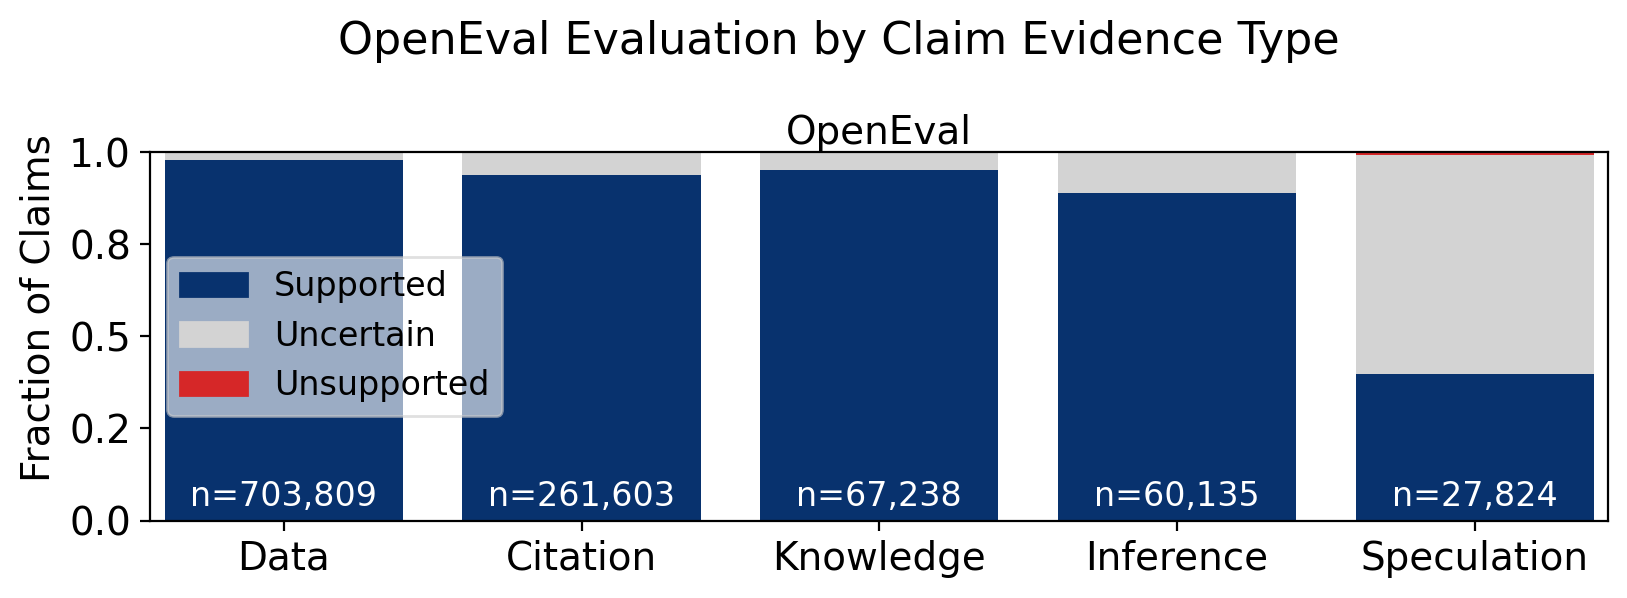

In [37]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# ---------- Helper Functions ----------
def parse_claim_ids(x):
    """Parse a string or iterable of claim IDs into a flat list of strings."""
    if isinstance(x, (list, tuple)):
        return list(x)
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except Exception:
            s = x.strip().strip("[]")
            if not s:
                return []
            return [t.strip().strip("'\"") for t in s.split(",") if t.strip()]
    return []

def parse_bracket_list(x):
    """Parse a bracketed string or iterable into a list of stripped strings."""
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return []
    if isinstance(x, (list, tuple, set)):
        return [str(v).strip() for v in x if str(v).strip()]
    s = str(x).strip()
    if s.startswith("[") and s.endswith("]"):
        s = s[1:-1].strip()
        if not s:
            return []
        return [t.strip() for t in s.split(",") if t.strip()]
    return [s] if s else []

def count_listlike(val):
    """Count number of elements in a list-like object or comma-separated string."""
    if val is None or (isinstance(val, float) and np.isnan(val)):
        return 0
    if isinstance(val, (list, tuple, set)):
        return len(val)
    s = str(val).strip().strip("[]")
    if not s:
        return 0
    return len([t for t in (x.strip() for x in s.split(",")) if t])

def normalize_eval(s):
    """Normalize evaluation_type to SUPPORTED / UNCERTAIN / UNSUPPORTED."""
    s = str(s).strip().upper()
    if s == "SUPPORTED":
        return "SUPPORTED"
    if s == "UNCERTAIN":
        return "UNCERTAIN"
    # Everything else goes to UNSUPPORTED (incl. NOT_SUPPORTED / REFUTED / etc.)
    return "UNSUPPORTED"

# Rank mapping for evaluation prioritization
EVAL_RANK = {"SUPPORTED": 2, "UNCERTAIN": 1, "UNSUPPORTED": 0}
EVAL_LABELS = {2: "SUPPORTED", 1: "UNCERTAIN", 0: "UNSUPPORTED"}

# ---------- Step 1: LLM Claim-Level Label Normalization ----------
def prep_evals(df, normalize_eval_func, rank_map):
    """Explode claim_ids, build claim_key, normalize & rank evaluation, single-result only."""
    df = df.copy()
    df["claim_id_list"] = df["claim_ids"].apply(parse_claim_ids)
    df = df.explode("claim_id_list", ignore_index=True).rename(columns={"claim_id_list": "claim_id"})
    df["claim_id"] = df["claim_id"].astype(str).str.strip()
    df["manuscript_id"] = df["manuscript_id"].astype(str).str.strip()
    df["claim_key"] = df["manuscript_id"] + "::" + df["claim_id"]

    # Only claims contributing to a single result
    claim_counts = df.groupby("claim_key").size()
    single_result_claims = claim_counts[claim_counts == 1].index
    df = df[df["claim_key"].isin(single_result_claims)].copy()

    df["eval_norm"] = df["evaluation_type"].apply(normalize_eval_func)
    df["eval_rank"] = df["eval_norm"].map(rank_map).astype(int)

    # For claims with more than one eval (shouldn't be, after filtering): take max rank
    claim_eval = df.groupby("claim_key", as_index=False)["eval_rank"].max()
    claim_eval["evaluation"] = claim_eval["eval_rank"].map(EVAL_LABELS)
    return claim_eval

claim_eval_llm  = prep_evals(df_llm[df_llm["in_post2023"]==False], normalize_eval, EVAL_RANK)

# ---------- Step 2: Claims Table to Single-Evidence-Type Claims ----------
claims = df_claims.copy()
claims["claim_id"] = claims["claim_id"].astype(str).str.strip()
claims["manuscript_id"] = claims["manuscript_id"].astype(str).str.strip()
claims["claim_key"] = claims["manuscript_id"] + "::" + claims["claim_id"]

claims["evidence_list"] = claims["evidence_type"].apply(parse_bracket_list)
claims["evidence_count"] = claims["evidence_list"].apply(count_listlike)
claims_single_evidence = claims[claims["evidence_count"] == 1].copy()
claims_single_evidence["evidence_cat"] = (
    claims_single_evidence["evidence_list"].apply(lambda x: x[0] if x else "")
)
claims_single_evidence["evidence_cat"] = claims_single_evidence["evidence_cat"].astype(str).str.strip()
claims_single_evidence = claims_single_evidence[claims_single_evidence["evidence_cat"].ne("")]

# Join LLM labels; drop unreviewed claims
claims_llm_reviewed = (
    claims_single_evidence.merge(claim_eval_llm[["claim_key", "evaluation"]], on="claim_key", how="left")
    .dropna(subset=["evaluation"])
    .copy()
)

# ---------- Step 3: Summarize by Evidence Type ----------
def summarize_fractions(df, cat_col="evidence_cat", eval_col="evaluation"):
    """Group by evidence_cat and evaluation, output fractions and claim counts."""
    counts = (
        df.groupby([cat_col, eval_col])["claim_key"]
          .nunique()
          .unstack(eval_col, fill_value=0)
    )
    # Guarantee columns order and existence
    for col in EVAL_LABELS.values():
        if col not in counts.columns:
            counts[col] = 0
    counts = counts[list(EVAL_LABELS.values())]
    fracs = counts.div(counts.sum(axis=1), axis=0)
    n_total = counts.sum(axis=1).rename("n_claims")
    return fracs.join(n_total)

summary_llm  = summarize_fractions(claims_llm_reviewed)

# Plotting order
desired_order = ["DATA", "CITATION", "KNOWLEDGE", "INFERENCE", "SPECULATION"]
evidence_types_present = [c for c in desired_order if c in summary_llm.index]
summary_llm  = summary_llm.reindex(evidence_types_present)

# ---------- Step 4: Print percent of SUPPORTED, UNCERTAIN, and UNSUPPORTED results that fall into SPECULATION or INFERENCE ----------
# (use single-type claims as in summary_llm above)

for eval_label in ["SUPPORTED", "UNCERTAIN", "UNSUPPORTED"]:
    claims_this_eval = claims_llm_reviewed[claims_llm_reviewed["evaluation"] == eval_label]
    n_total = len(claims_this_eval)
    n_inf_spec = claims_this_eval["evidence_cat"].isin(["SPECULATION", "INFERENCE"]).sum()
    pct_inf_spec = 100 * n_inf_spec / n_total if n_total > 0 else 0.0
    print(f"Percentage of {eval_label.lower()} results that fall into speculation or inference: {pct_inf_spec:.2f}% ({n_inf_spec} of {n_total})")

# ---------- Step 5: Plot ----------
def plot_stacked_bar(ax, summary, fontsize=14, label_bar_color="white", color_map=None):
    x = np.arange(len(summary.index))
    bottom = np.zeros_like(x, dtype=float)
    default_color_map = {
        "SUPPORTED": plt.get_cmap('Blues')(0.99),
        "UNCERTAIN": "lightgrey",
        "UNSUPPORTED": "tab:red",
    }
    # Allow passing a color_map for legend consistency
    color_map = color_map if color_map is not None else default_color_map
    for eval_name in ["SUPPORTED", "UNCERTAIN", "UNSUPPORTED"]:
        vals = summary[eval_name].to_numpy()
        ax.bar(x, vals, bottom=bottom, color=color_map[eval_name], label=eval_name)
        bottom += vals
    ax.set_ylim(0, 1)
    ax.set_title("OpenEval", fontsize=fontsize, pad=0)
    for i, n in enumerate(summary["n_claims"].astype(int).to_numpy()):
        ax.text(i, 0.02, f"n={n:,}", ha="center", va="bottom",
                fontsize=fontsize-2, color=label_bar_color)
    ax.set_xticks(x)
    ax.margins(x=0.01)
    # Format y ticks to only one decimal
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.1f}"))

fontsize = 14

# Consistent color map for bars and legend
legend_color_map = {
    "SUPPORTED": plt.get_cmap('Blues')(0.99),
    "UNCERTAIN": "lightgrey",
    "UNSUPPORTED": "tab:red",
}

fig, ax = plt.subplots(1, 1, figsize=(8, 3))
fig.text(0, 0.5, "Fraction of Claims", va='center', rotation='vertical', fontsize=fontsize, ha='center')
fig.suptitle("OpenEval Evaluation by Claim Evidence Type", fontsize=fontsize + 2, y=0.98)

plot_stacked_bar(ax, summary_llm, fontsize=fontsize, color_map=legend_color_map)

xtick_labels = [c.capitalize() for c in summary_llm.index]
ax.set_xticklabels(xtick_labels, rotation=0, fontsize=fontsize)
ax.tick_params(axis="both", labelsize=fontsize)
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.1f}"))

# Single legend
handles = [
    plt.Rectangle((0, 0), 1, 1, color=legend_color_map["SUPPORTED"]),
    plt.Rectangle((0, 0), 1, 1, color=legend_color_map["UNCERTAIN"]),
    plt.Rectangle((0, 0), 1, 1, color=legend_color_map["UNSUPPORTED"]),
]
labels = ["Supported", "Uncertain", "Unsupported"]
ax.legend(handles, labels, loc="center left", frameon=True, fontsize=fontsize-2, framealpha=0.6)

plt.tight_layout()
fig.savefig("figures/3_openeval_by_evidence_type.png", dpi=300, bbox_inches="tight")
plt.show()


# # of claims versus manuscript length

Found 16,087 manuscripts with manuscript.md
R^2 (number of claims vs manuscript length): 0.039


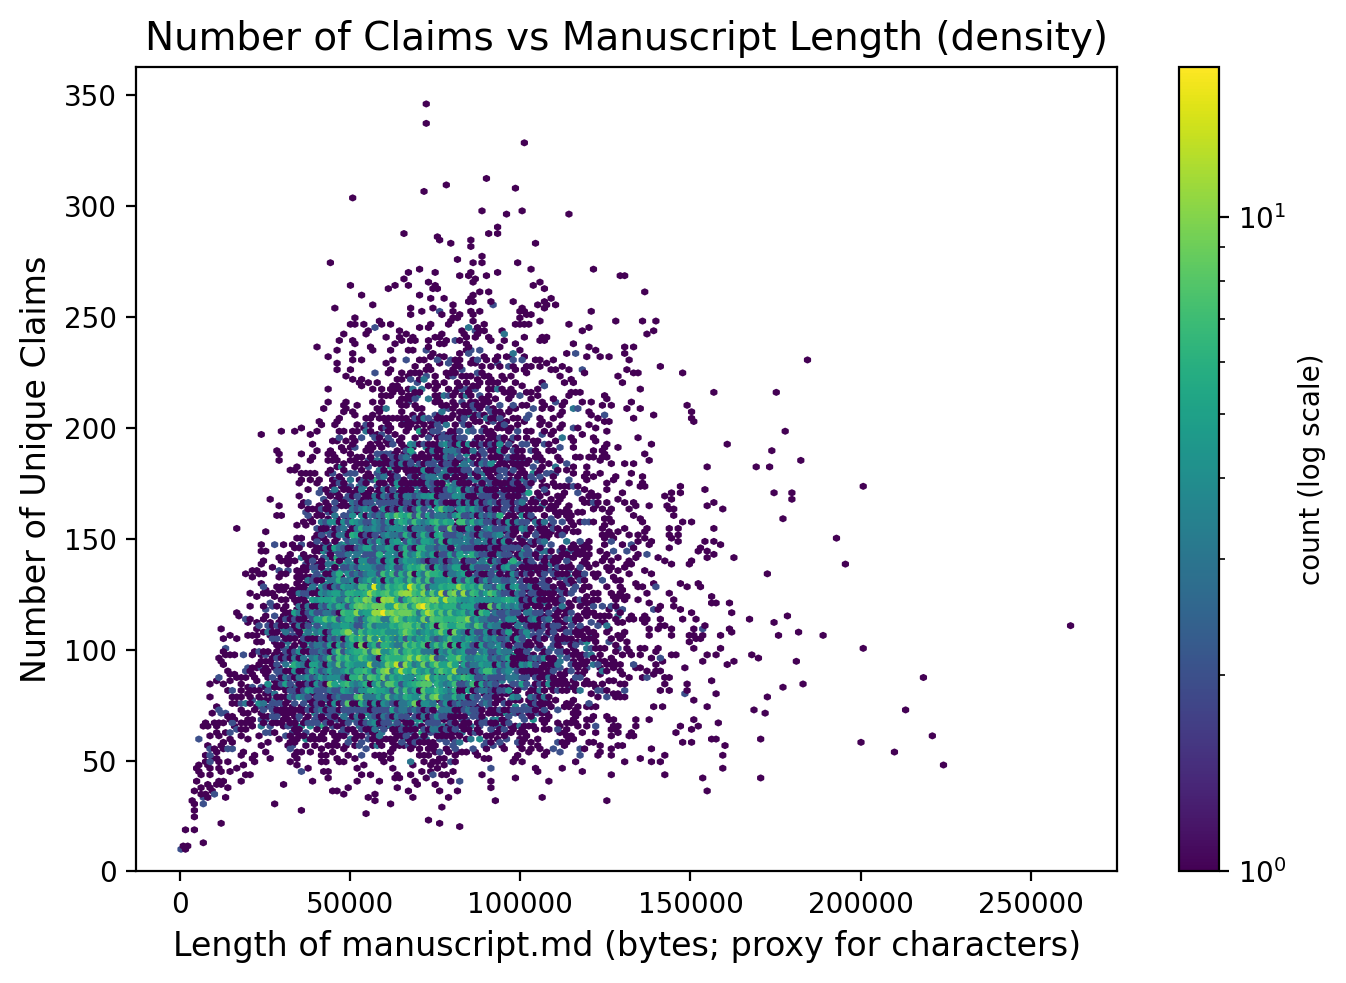

In [63]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from sklearn.metrics import r2_score

# ----------------------------
# Config
# ----------------------------
md_base_dir = "../manuscripts"

# Plot options
use_density_plot = True   # True = hexbin density (recommended). False = rasterized scatter
dot_color = "grey"
dot_size = 1              # only used for scatter
dot_alpha = 0.15          # only used for scatter

# ----------------------------
# 1) Vectorized: unique-claim counts per (manuscript_id, version)
# ----------------------------
required_cols = {"manuscript_id", "version", "claim_id"}
if not required_cols.issubset(df_claims.columns):
    raise ValueError(f"df_claims must contain columns: {sorted(required_cols)}")

claims_per_manuscript = (
    df_claims
    .groupby(["manuscript_id", "version"])["claim_id"]
    .nunique()
    .reset_index()
    .rename(columns={"claim_id": "num_claims"})
)

# ----------------------------
# 2) Fast: manuscript lengths (characters-ish) from file bytes
#    (binary read is much faster than decoding text)
# ----------------------------
records = []
missing_files = 0
read_errors = 0

for manuscript_id, version, num_claims in claims_per_manuscript.itertuples(index=False):
    md_path = os.path.join(md_base_dir, str(manuscript_id), str(version), "manuscript.md")
    if not os.path.isfile(md_path):
        missing_files += 1
        continue

    try:
        with open(md_path, "rb") as f:
            length = len(f.read())  # length in bytes; fast proxy for "characters"
    except OSError:
        read_errors += 1
        continue

    records.append((manuscript_id, version, length, int(num_claims)))

df_plot = pd.DataFrame(
    records,
    columns=["manuscript_id", "version", "manuscript_length", "num_claims"]
).sort_values("manuscript_length")

manuscript_lengths_sorted = df_plot["manuscript_length"].to_numpy()
num_claims_sorted = df_plot["num_claims"].to_numpy()

print(f"Found {len(df_plot):,} manuscripts with manuscript.md")
if missing_files:
    print(f"Missing manuscript.md for {missing_files:,} (manuscript_id, version) pairs")
if read_errors:
    print(f"Read errors for {read_errors:,} files")

# ----------------------------
# 3) R^2 (linear fit)
# ----------------------------
x = manuscript_lengths_sorted
y = num_claims_sorted

if len(x) > 1:
    coeffs = np.polyfit(x, y, 1)
    y_pred = np.poly1d(coeffs)(x)
    r2 = r2_score(y, y_pred)
    print(f"R^2 (number of claims vs manuscript length): {r2:.3f}")

# ----------------------------
# 4) Plot (fast)
# ----------------------------
plt.figure(figsize=(7, 5))

if use_density_plot:
    # Density plot scales to millions of points easily
    plt.hexbin(x, y, gridsize=200, mincnt=1, norm=LogNorm())
    plt.colorbar(label="count (log scale)")
    plt.title("Number of Claims vs Manuscript Length (density)", fontsize=14)
else:
    # If you still want scatter: rasterize + tiny markers
    plt.scatter(x, y, s=dot_size, alpha=dot_alpha, color=dot_color,
                rasterized=True, linewidths=0)
    plt.title("Number of Claims vs Manuscript Length", fontsize=14)

plt.xlabel("Length of manuscript.md (bytes; proxy for characters)", fontsize=12)
plt.ylabel("Number of Unique Claims", fontsize=12)
plt.ylim(bottom=0)
plt.tight_layout()
plt.savefig("figures/3_claims_vs_manuscript_length.png", dpi=300, bbox_inches="tight")
plt.show()

# Plot claim types

/Users/laura/anaconda3/lib/python3.13/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/Users/laura/anaconda3/lib/python3.13/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves 

<Figure size 800x600 with 0 Axes>

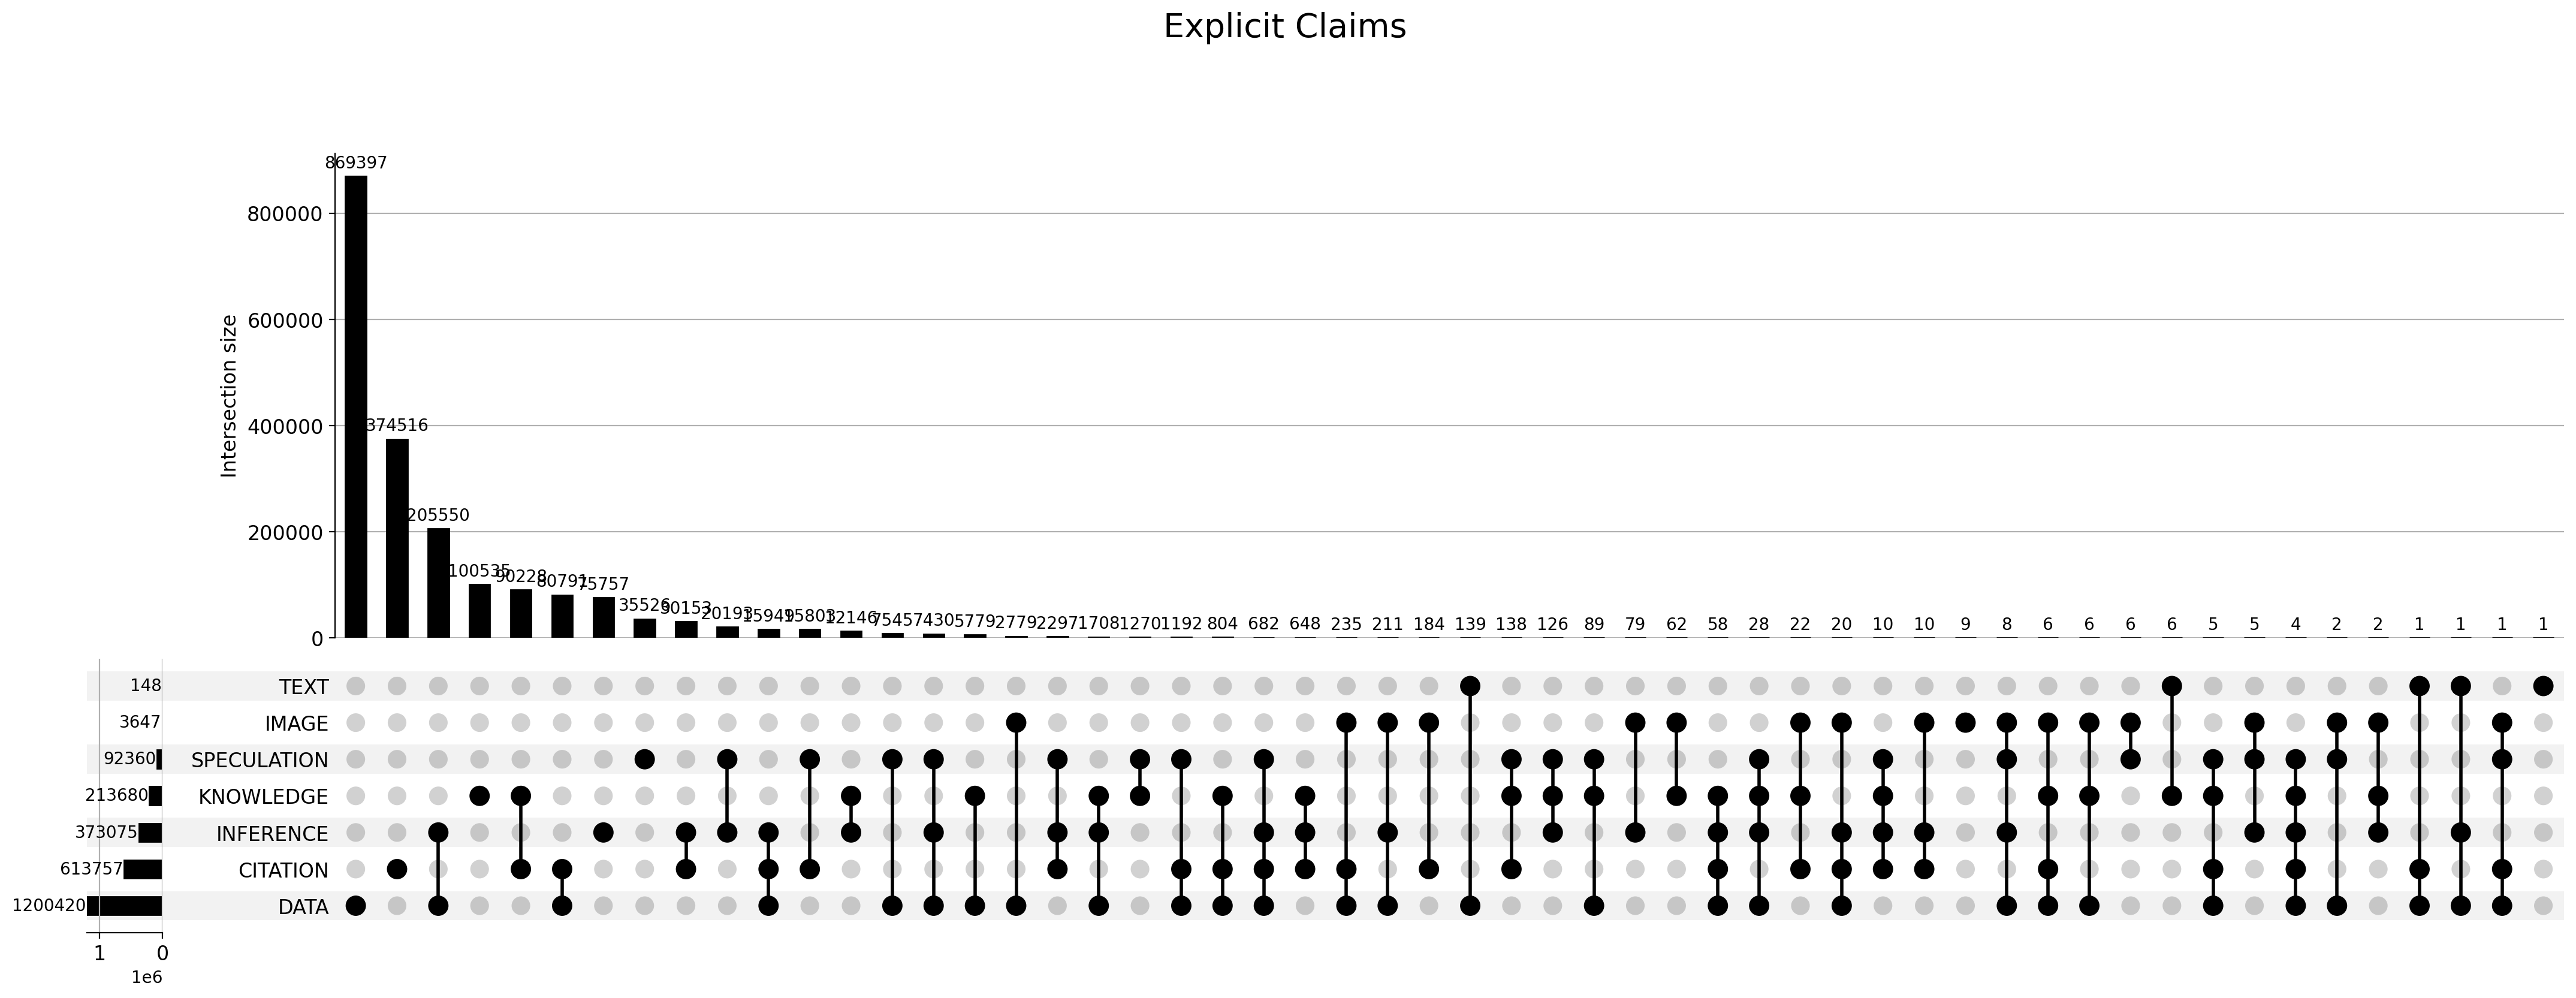

/Users/laura/anaconda3/lib/python3.13/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/Users/laura/anaconda3/lib/python3.13/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves 

<Figure size 800x600 with 0 Axes>

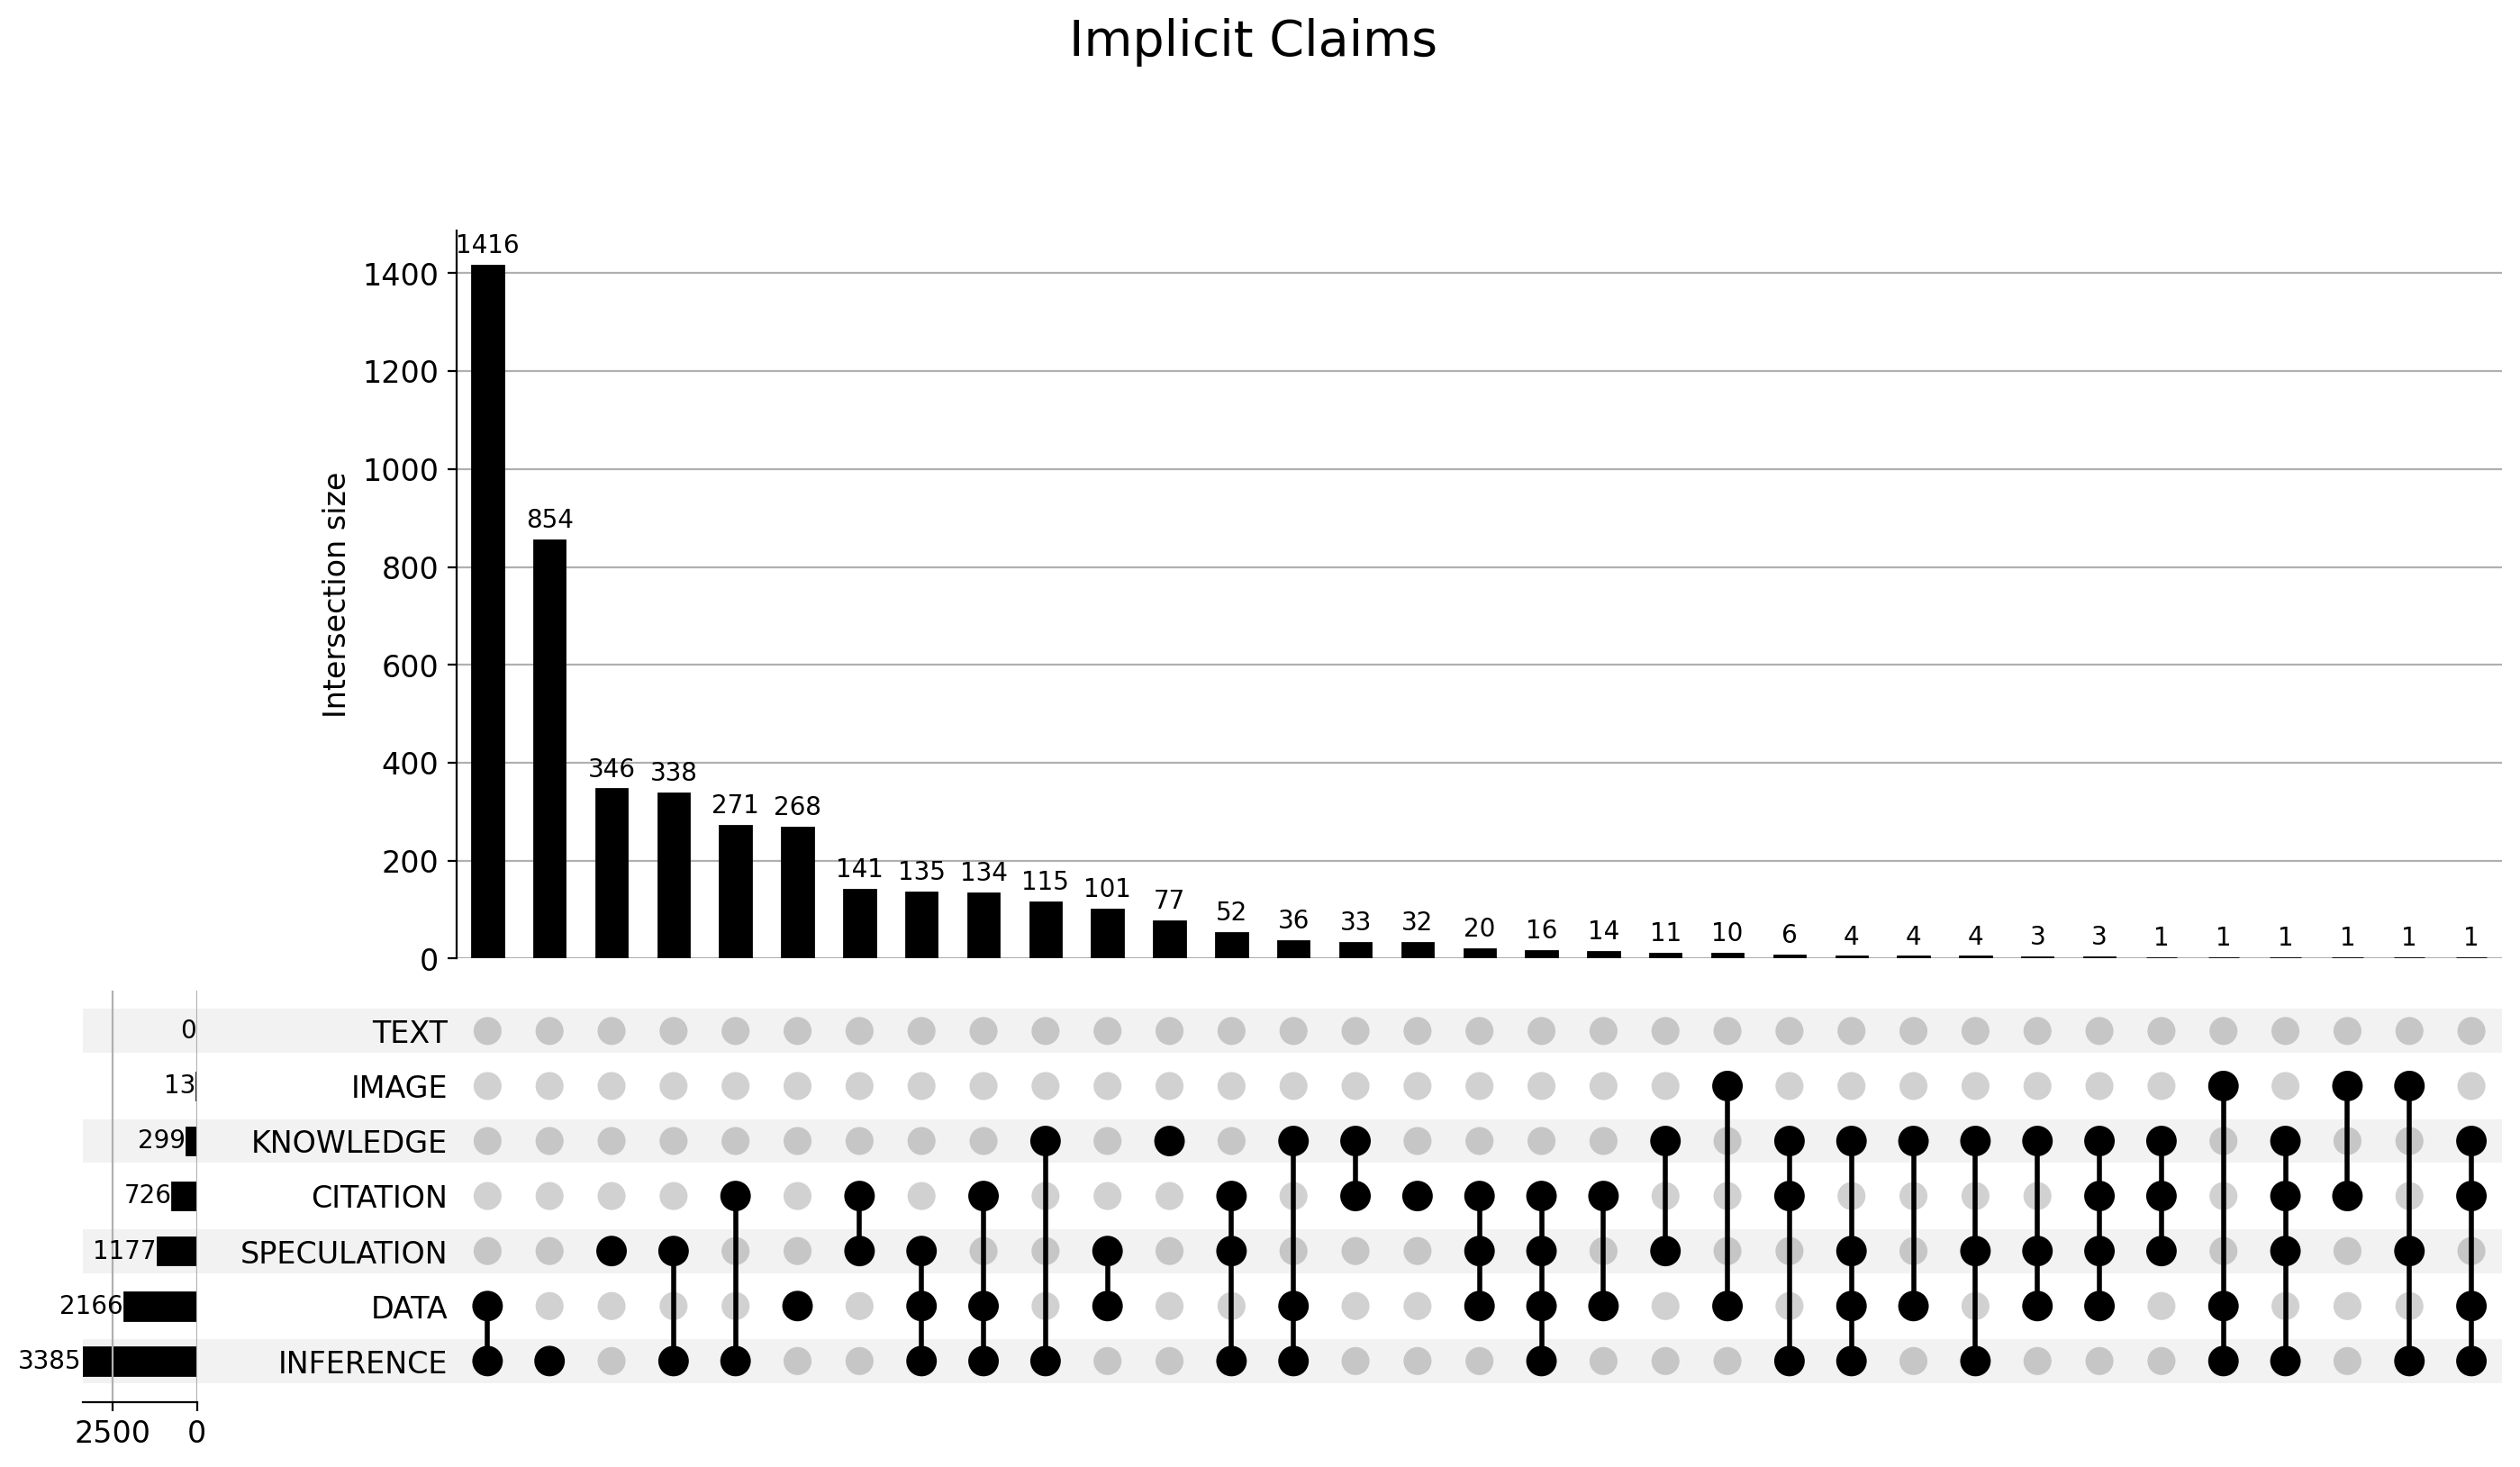

In [64]:
# pip install upsetplot

import re
import pandas as pd
import matplotlib.pyplot as plt
from upsetplot import UpSet

def parse_evidence_types(val):
    if val is None or (isinstance(val, float) and pd.isna(val)) or (isinstance(val, str) and not val.strip()):
        return []
    if isinstance(val, (list, tuple, set)):
        return sorted({str(x).strip().upper() for x in val if str(x).strip()})

    s = str(val).strip()
    s = re.sub(r"^\[|\]$", "", s)
    return sorted({t.strip().upper() for t in s.split(",") if t.strip()})

# --- prepare dataframe ---
df = df_claims.copy()
df["claim_type_norm"] = df["claim_type"].astype(str).str.strip().str.upper()
df = df[df["claim_type_norm"].isin(["EXPLICIT", "IMPLICIT"])].copy()

df["evidence_types_list"] = df["evidence_type"].apply(parse_evidence_types)

all_ev_types = sorted({ev for lst in df["evidence_types_list"] for ev in lst})

# indicator matrix
indicators = pd.DataFrame(
    {ev: df["evidence_types_list"].apply(lambda xs, ev=ev: ev in xs) for ev in all_ev_types},
    index=df.index,
)

# --- plot separately for each claim type ---
for ct in ["EXPLICIT", "IMPLICIT"]:
    ind_sub = indicators.loc[df["claim_type_norm"] == ct]

    if ind_sub.empty:
        print(f"No rows for {ct}")
        continue

    # Build the MultiIndex Series expected by upsetplot
    s = (
        ind_sub
        .astype(bool)
        .groupby(all_ev_types)
        .size()
    )
    s.index = s.index.set_names(all_ev_types)

    plt.figure(figsize=(8, 6))
    upset = UpSet(
        s,
        show_counts=True,
        sort_by="cardinality",
        intersection_plot_elements=12,
    )
    upset.plot()

    plt.suptitle(f"{ct.capitalize()} Claims", y=1.02, fontsize=20)
    ax = plt.gca()
    # Set all axis labels fontsize
    ax.set_xlabel(ax.get_xlabel(), fontsize=12)
    ax.set_ylabel(ax.get_ylabel(), fontsize=12)
    # Set ticklabel font size for all axes in the figure
    for axes in plt.gcf().axes:
        axes.tick_params(axis='both', labelsize=12)
        # Also try updating axis title font size if it's present
        if axes.get_title():
            axes.set_title(axes.get_title(), fontsize=12)
        if axes.get_xlabel():
            axes.set_xlabel(axes.get_xlabel(), fontsize=12)
        if axes.get_ylabel():
            axes.set_ylabel(axes.get_ylabel(), fontsize=12)
    plt.savefig(f"figures/3_evidence_types_upset_{ct}.png", dpi=300, bbox_inches="tight")
    plt.show()

In [65]:
def prep_long(df: pd.DataFrame) -> pd.DataFrame:
    """
    Produces a long-form table with exploded evidence_type and source_type.

    Output columns include:
      - manuscript_id, claim_id, claim_type
      - evidence_cat (single category)
      - source_cat (single category)
    """
    d = df.copy()
    # Ensure these exist
    for col in ["evidence_type", "source_type", "claim_type", "manuscript_id", "claim_id"]:
        if col not in d.columns:
            raise KeyError(f"Missing expected column: {col}")

    d["evidence_list"] = d["evidence_type"].map(parse_bracket_list)
    d["source_list"]   = d["source_type"].map(parse_bracket_list)

    # explode evidence first
    long = d.explode("evidence_list", ignore_index=True)
    long = long.rename(columns={"evidence_list": "evidence_cat"})

    # then explode source types
    long = long.explode("source_list", ignore_index=True)
    long = long.rename(columns={"source_list": "source_cat"})

    # clean empties
    long["evidence_cat"] = long["evidence_cat"].fillna("").astype(str).str.strip()
    long["source_cat"]   = long["source_cat"].fillna("").astype(str).str.strip()

    long = long[(long["evidence_cat"] != "") & (long["source_cat"] != "")]
    return long

def parse_bracket_list(x):
    """
    Turns strings like "[TEXT, IMAGE]" or "[CITATION, KNOWLEDGE]" into ["TEXT","IMAGE"].
    If already list/tuple/set -> list.
    If NaN/None -> [].
    Else -> [str(x)].
    """
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return []
    if isinstance(x, (list, tuple, set)):
        return [str(v).strip() for v in x if str(v).strip()]
    s = str(x).strip()
    m = _list_re.match(s)
    if m:
        inner = m.group(1).strip()
        if not inner:
            return []
        return [t.strip() for t in inner.split(",") if t.strip()]
    return [s] if s else []

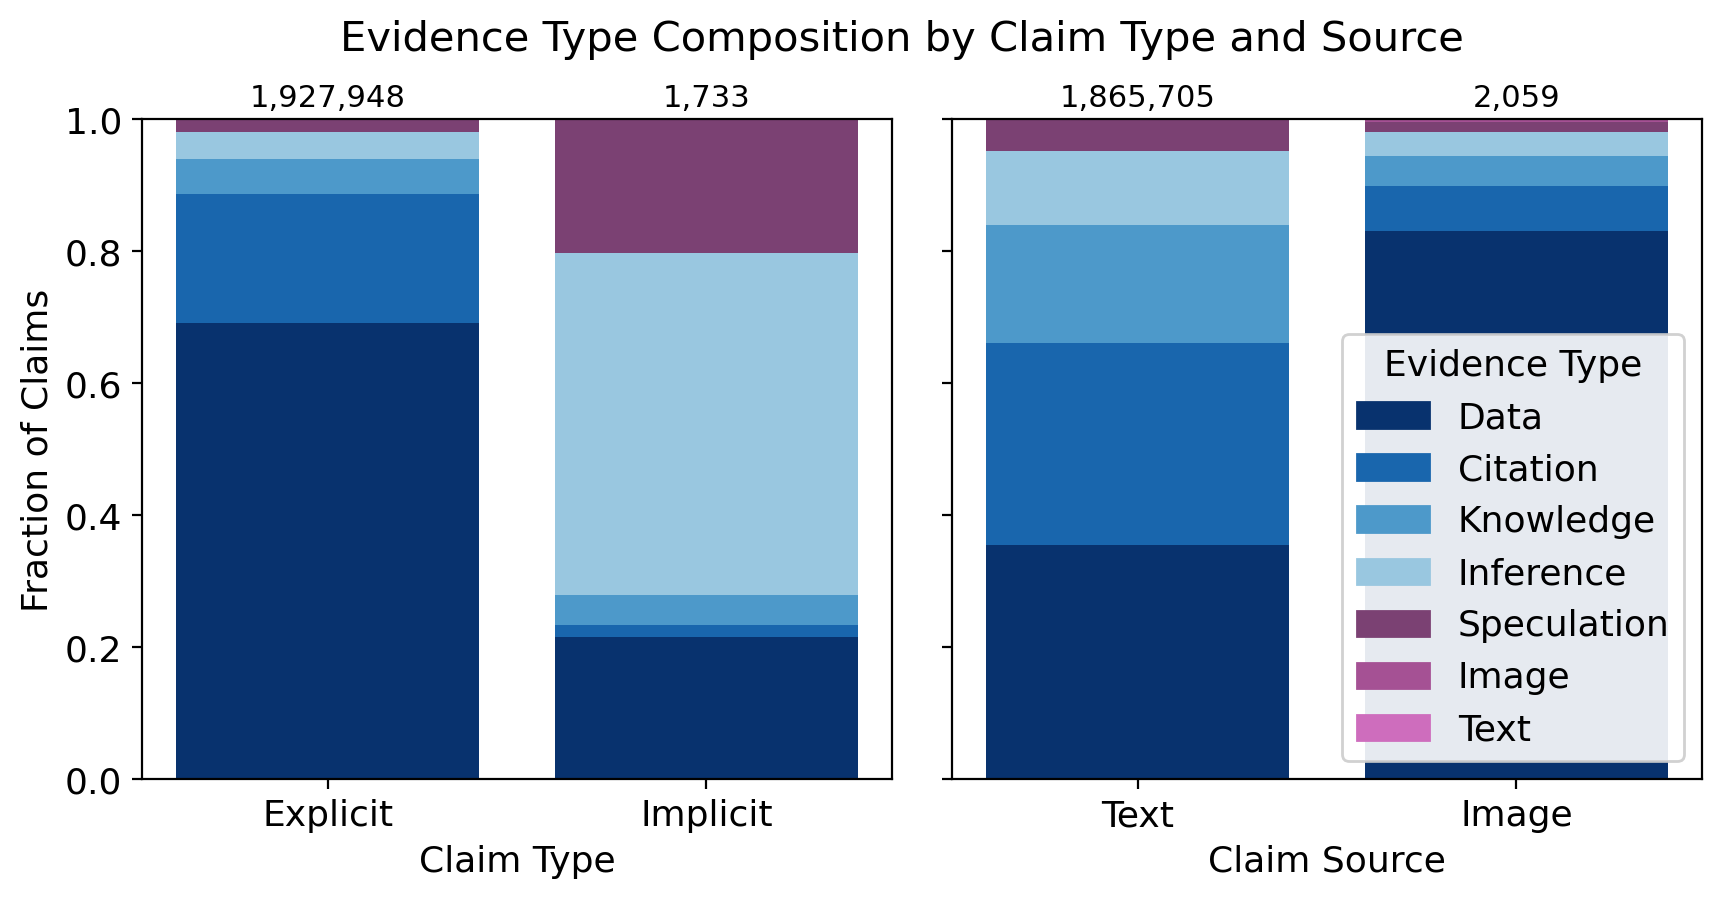

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import MaxNLocator

def plot_evidence_by_claim_and_source_single_evidence(
    df_claims,
    top_k_evidence=10,
    normalize_within_group=True,
    bar_width=0.8,
    fontsize=13,
    max_source_ticks=10,
    figsize=(10, 5),
):
    long_all = prep_long(df_claims).copy()

    # ----------------------------
    # Helpers
    # ----------------------------
    def _count_listlike(val) -> int:
        if val is None or (isinstance(val, float) and np.isnan(val)):
            return 0
        if isinstance(val, (list, tuple, set)):
            return len(val)
        s = str(val).strip().strip("[]").strip()
        if not s:
            return 0
        return len([t for t in (x.strip() for x in s.split(",")) if t])

    def _cap(label) -> str:
        s = "" if label is None else str(label)
        return s.lower().capitalize()

    def _bucket_top_k(series: pd.Series, k: int, other="OTHER"):
        top = series.value_counts().head(k).index.tolist()
        return np.where(series.isin(top), series, other)

    def _stacked_table(df: pd.DataFrame, group_col: str, cat_col: str, cat_order: list) -> pd.DataFrame:
        return (
            df.groupby([group_col, cat_col])
              .size()
              .unstack(fill_value=0)
              .reindex(columns=cat_order, fill_value=0)
        )

    def _draw_stacked_bars(ax, df, group_col, group_order, cat_order, cat_label_map, xlabel, show_legend_labels):
        raw = _stacked_table(df, group_col, "evidence_cat_k", cat_order)
        totals = raw.sum(axis=1)

        if normalize_within_group:
            denom = raw.sum(axis=1).replace(0, np.nan)
            tab = raw.div(denom, axis=0).fillna(0.0)
            ylab = "Fraction of Claims"
            y_top_for_labels = 1.0
            ax.set_ylim(0, 1)
        else:
            tab = raw
            ylab = "Count"
            y_top_for_labels = float(raw.sum(axis=1).max()) if len(raw) else 1.0

        x = np.arange(len(group_order))
        bottoms = np.zeros(len(group_order), dtype=float)

        # palette = ["#495867", "#577399", "#BDD5EA", "#956E8C", "#DDCAD9", "lightgrey", "#FE5F55"]
        palette = [
            plt.get_cmap('Blues')(0.99),
            plt.get_cmap('Blues')(0.79),
            plt.get_cmap('Blues')(0.59),
            plt.get_cmap('Blues')(0.39),
            "#7b4173",
            "#a55194",
            "#ce6dbd",
            "#de9ed6",
        ]
        colors = (palette * ((len(cat_order) // len(palette)) + 1))[:len(cat_order)]
        color_map = {cat: colors[i] for i, cat in enumerate(cat_order)}

        # cmap = plt.get_cmap('tab20b')
        # colors = [cmap(i) for i in range(len(cat_order))]
        # color_map = {cat: colors[i] for i, cat in enumerate(cat_order)}

        for cat in cat_order:
            heights = np.array([tab.loc[g, cat] if g in tab.index else 0.0 for g in group_order], dtype=float)
            ax.bar(
                x,
                heights,
                width=bar_width,
                bottom=bottoms,
                color=color_map[cat],
                edgecolor="none",
                label=cat_label_map.get(cat, str(cat)) if show_legend_labels else None,
            )
            bottoms += heights

        # N labels above bars (counts even when normalized)
        for i, g in enumerate(group_order):
            n_g = int(totals.get(g, 0))
            if n_g > 0:
                ax.text(
                    x[i],
                    y_top_for_labels + 0.01 * y_top_for_labels,
                    f"{n_g:,}",
                    ha="center",
                    va="bottom",
                    fontsize=fontsize - 2,
                )

        ax.set_xticks(x)
        ax.set_xticklabels([_cap(g) for g in group_order], fontsize=fontsize, rotation=0)
        ax.set_xlabel(xlabel, fontsize=fontsize)
        ax.tick_params(axis="x", labelsize=fontsize)
        ax.tick_params(axis="y", labelsize=fontsize)
        ax.margins(x=0.05)

        return ylab, color_map

    # ----------------------------
    # Left: single evidence
    # ----------------------------
    long_left = long_all.copy()
    if "evidence_types_list" in long_left.columns:
        ev_count = long_left["evidence_types_list"].apply(_count_listlike)
    else:
        if "evidence_type" not in long_left.columns:
            raise ValueError("Need 'evidence_types_list' or 'evidence_type' to filter to single-evidence claims.")
        ev_count = long_left["evidence_type"].apply(_count_listlike)

    long_left = long_left[ev_count == 1].copy()
    if long_left.empty:
        raise ValueError("No rows left after filtering to claims with exactly one evidence type.")

    long_left["evidence_cat_k"] = _bucket_top_k(long_left["evidence_cat"], top_k_evidence, other="OTHER")
    claim_order = long_left["claim_type"].value_counts().index.tolist()
    evidence_order_left = long_left["evidence_cat_k"].value_counts().index.tolist()
    evidence_label_left = {ev: _cap(ev) for ev in evidence_order_left}

    # ----------------------------
    # Right: single source
    # ----------------------------
    long_right = long_all.copy()
    if "source_type" in long_right.columns:
        st_count = long_right["source_type"].apply(_count_listlike)
        long_right = long_right[st_count == 1].copy()

    if long_right.empty:
        raise ValueError("No rows left after filtering to claims with exactly one source type.")
    if "source_cat" not in long_right.columns:
        raise ValueError("Expected 'source_cat' from prep_long(df_claims).")

    long_right["evidence_cat_k"] = _bucket_top_k(long_right["evidence_cat"], top_k_evidence, other="OTHER")
    evidence_order_right = long_right["evidence_cat_k"].value_counts().index.tolist()
    evidence_label_right = {ev: _cap(ev) for ev in evidence_order_right}

    source_order = long_right["source_cat"].value_counts().index.tolist()
    if len(source_order) > max_source_ticks:
        top_sources = source_order[:max_source_ticks]
        long_right["source_cat_k"] = np.where(long_right["source_cat"].isin(top_sources), long_right["source_cat"], "OTHER")
        source_order_k = [*top_sources, "OTHER"]
    else:
        long_right["source_cat_k"] = long_right["source_cat"]
        source_order_k = source_order

    # ----------------------------
    # Plot
    # ----------------------------
    fig = plt.figure(figsize=figsize)
    gs = GridSpec(1, 2, width_ratios=[1, 1], figure=fig)
    ax_claim = fig.add_subplot(gs[0, 0])
    ax_source = fig.add_subplot(gs[0, 1], sharey=ax_claim)

    ylab, color_map_left = _draw_stacked_bars(
        ax_claim,
        long_left,
        group_col="claim_type",
        group_order=claim_order,
        cat_order=evidence_order_left,
        cat_label_map=evidence_label_left,
        xlabel="Claim Type",
        show_legend_labels=True,
    )
    ax_claim.set_ylabel(ylab, fontsize=fontsize)
    ax_claim.yaxis.set_major_locator(MaxNLocator(5))

    _ylab2, _ = _draw_stacked_bars(
        ax_source,
        long_right,
        group_col="source_cat_k",
        group_order=source_order_k,
        cat_order=evidence_order_right,
        cat_label_map=evidence_label_right,
        xlabel="Claim Source",
        show_legend_labels=False,
    )

    # --- Desired behavior ---
    # Left: show y ticks + labels
    ax_claim.tick_params(axis="y", which="both", left=True, labelleft=True)

    # Right: keep y axis + tick marks, but hide tick labels only
    ax_source.tick_params(axis="y", which="both", left=True, labelleft=False)

    # Keep the left spine visible on the right subplot (do NOT hide it)
    ax_source.spines["left"].set_visible(True)

    # Legend (left only)
    handles = [mpatches.Patch(color=color_map_left[ev], label=evidence_label_left[ev]) for ev in evidence_order_left]
    leg = ax_source.legend(
        handles=handles,
        title="Evidence Type",
        loc="lower right",
        fontsize=fontsize,
        title_fontsize=fontsize,
        frameon=True,
    )
    if leg is not None:
        leg.get_frame().set_alpha(0.9)

    # Spacing so left y tick labels have room
    fig.subplots_adjust(left=0.12, bottom=0.22, wspace=0.08)

    fig.suptitle("Evidence Type Composition by Claim Type and Source", fontsize=fontsize + 2, y=0.98)

    return fig, (ax_claim, ax_source)

fig, axes = plot_evidence_by_claim_and_source_single_evidence(
    df_claims,
    top_k_evidence=10,
    normalize_within_group=True,
)

fig.savefig("figures/3_evidence_composition_by_claim_and_source.png", dpi=300, bbox_inches="tight")

plt.show()


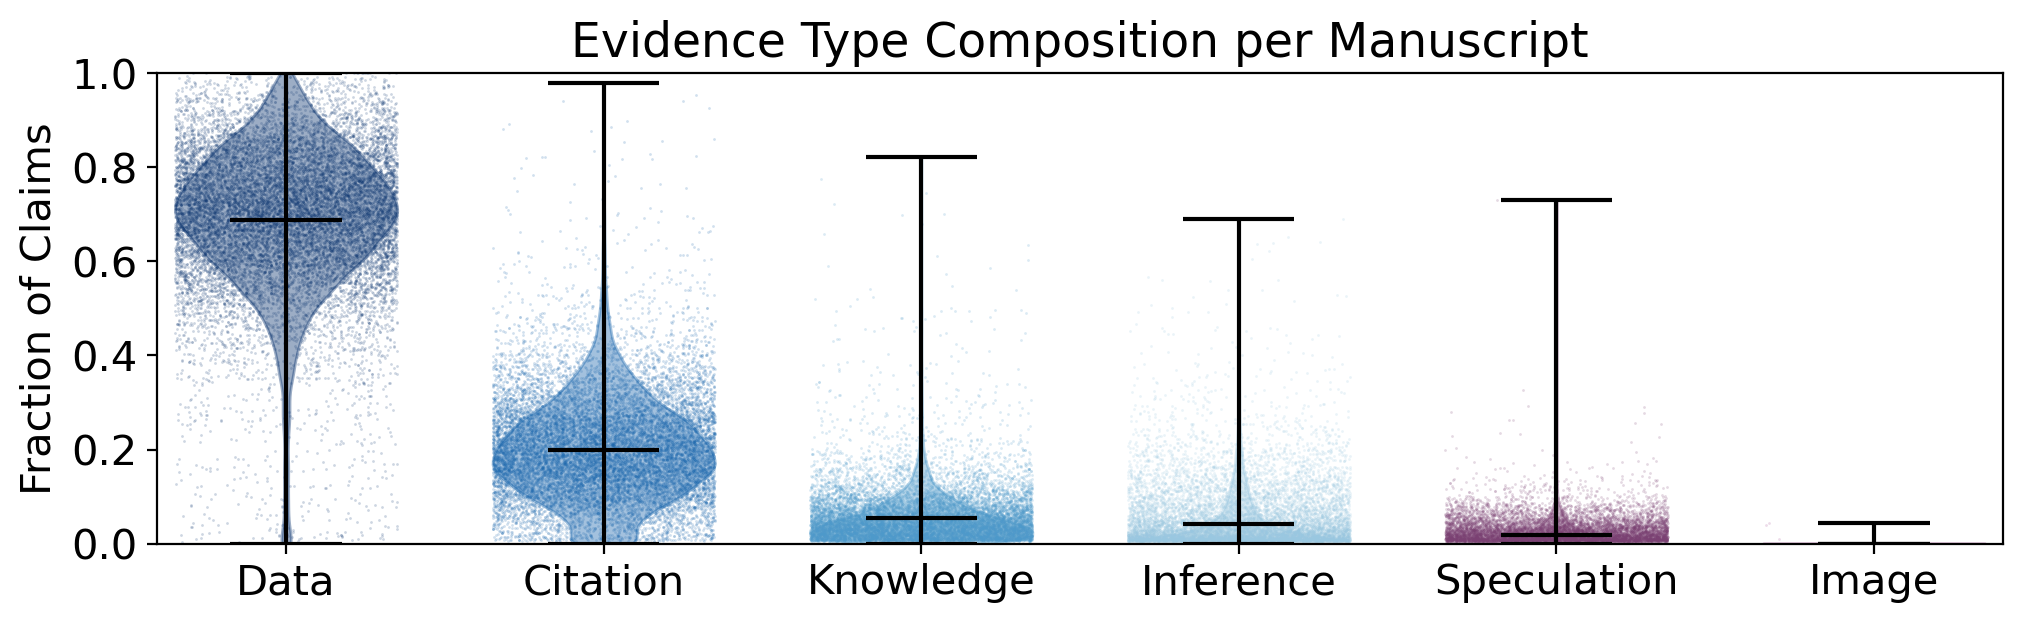

In [67]:
# Set fontsize for ticklabels, axis labels, and titles
fontsize = 15

def _topk_categories(series: pd.Series, k: int = 8):
    vc = series.value_counts()
    keep = list(vc.head(k).index)
    return keep

def plot_evidence_fractions_violin(df_claims: pd.DataFrame, top_k: int = 8, min_claims: int = 50, fontsize: int = fontsize):
    """
    Violin plot: distributions of evidence category fractions across manuscripts,
    including only claims with exactly one evidence type.
    Each violin shows the distribution (across manuscripts) of the proportion of claims using that evidence type.
    Overlays a scatter plot of individual data points.
    """

    long = prep_long(df_claims).copy()

    # --- Filter for claims with exactly one evidence type, as in the reference code ---
    def _count_listlike(val) -> int:
        if val is None or (isinstance(val, float) and np.isnan(val)):
            return 0
        if isinstance(val, (list, tuple, set)):
            return len(val)
        s = str(val).strip().strip("[]").strip()
        if not s:
            return 0
        return len([t for t in (x.strip() for x in s.split(",")) if t])

    if "evidence_types_list" in long.columns:
        ev_count = long["evidence_types_list"].apply(_count_listlike)
    else:
        if "evidence_type" not in long.columns:
            raise ValueError("Need 'evidence_types_list' or 'evidence_type' to filter to single-evidence claims.")
        ev_count = long["evidence_type"].apply(_count_listlike)

    long = long[ev_count == 1].copy()
    if long.empty:
        raise ValueError("No rows left after filtering to claims with exactly one evidence type.")

    # topk evidence types, rest as "OTHER"
    keep = _topk_categories(long["evidence_cat"], k=top_k)
    long["evidence_cat_k"] = np.where(long["evidence_cat"].isin(keep), long["evidence_cat"], "OTHER")

    manus_sizes = long.groupby("manuscript_id").size()
    good_manus = manus_sizes[manus_sizes >= min_claims].index
    long = long[long["manuscript_id"].isin(good_manus)]

    evidence_order = (
        pd.Series(long["evidence_cat_k"])
        .value_counts()
        .index.tolist()
    )

    # Manuscript × evidence tabulation (proportions)
    tab = (
        long.groupby(["manuscript_id", "evidence_cat_k"])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=evidence_order, fill_value=0)
    )
    props = tab.div(tab.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)

    # Prepare data for violinplot: list of arrays, one per evidence type, each array is the props per manuscript
    data = [props[e].values for e in evidence_order]

    fig, ax = plt.subplots(1, 1, figsize=(10,3), constrained_layout=True)
    vp = ax.violinplot(data, showmeans=True, widths=0.7)

    # --- Use a color palette for violin colors, matching the order and looping as needed ---
    palette = [
        plt.get_cmap('Blues')(0.99),
        plt.get_cmap('Blues')(0.79),
        plt.get_cmap('Blues')(0.59),
        plt.get_cmap('Blues')(0.39),
        "#7b4173",
        "#a55194",
        "#ce6dbd",
        "#de9ed6",
    ]
    # Extend palette if fewer colors than violins
    from itertools import cycle, islice
    violin_colors = list(islice(cycle(palette), len(evidence_order)))

    # Set each violin body color
    for pc, violin_color in zip(vp['bodies'], violin_colors):
        pc.set_facecolor(violin_color)
        pc.set_edgecolor(violin_color)
        pc.set_alpha(0.4)

    # Always keep mean/median/statistics lines in violin black
    for partname in ['cmeans', 'cmins', 'cmaxes', 'cmedians', 'cbars']:
        part = vp.get(partname)
        if part is not None:
            # May be a LineCollection or list of lines (for means, bars, etc)
            if hasattr(part, '__len__') and len(part) == len(evidence_order):
                for line in part:
                    if hasattr(line, "set_color"):
                        line.set_color("black")
                    elif hasattr(line, "set_edgecolor"):
                        line.set_edgecolor("black")
                    line.set_linewidth(1.5)
                    if hasattr(line, "set_alpha"):
                        line.set_alpha(1)
            else:
                # fallback: just use black
                if hasattr(part, "set_color"):
                    part.set_color("black")
                elif hasattr(part, "set_edgecolor"):
                    part.set_edgecolor("black")
                part.set_linewidth(1.5)
                if hasattr(part, "set_alpha"):
                    part.set_alpha(1)

    ax.set_xticks(np.arange(1, len(evidence_order)+1))
    xtick_labels = [e.capitalize() for e in evidence_order]
    ax.set_xticklabels(xtick_labels, rotation=0, fontsize=fontsize)
    # ax.set_xlabel("Evidence Type", fontsize=fontsize)
    ax.set_ylabel("Fraction of Claims", fontsize=fontsize)
    ax.set_title("Evidence Type Composition per Manuscript", fontsize=fontsize+2)
    ax.margins(x=0.01)
    ax.set_ylim(0, 1)
    ax.tick_params(axis='y', labelsize=fontsize)

    # Overlay scatter plot (strip plot) with less wide horizontal jitter/error
    for i, (arr, violin_color) in enumerate(zip(data, violin_colors)):
        jitter = (np.random.rand(len(arr)) - 0.5) * 0.7
        x_arr = np.full_like(arr, i+1, dtype=float) + jitter
        # Overlay scatter dots (alpha and size as desired)
        ax.scatter(x_arr, arr, alpha=0.2, color=violin_color, s=1, linewidths=0)

    return fig, ax

# 4) Evidence category fraction violin plot across manuscripts
fig, ax = plot_evidence_fractions_violin(df_claims, top_k=8, min_claims=50, fontsize=fontsize)
fig.savefig("figures/3_evidence_fractions_violin.png", dpi=300, bbox_inches="tight")

plt.show()